# Measuring emission line fluxes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits

import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy as upy

import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian, to_vel, FWHM, dV, save_catalog
from magE.plotutils import * 
from magE.constutils import *

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [2]:
# read the data
import pandas as pd
galname = 'J0021'
j0021 = pd.read_csv(galname + '.csv')

wave = j0021['wave'].to_numpy()
flux = j0021['flux'].to_numpy()
err = j0021['noise'].to_numpy()
igal = np.argmax(np.array(galnames) == 'J0021')

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# Main lines
        
# [NII]6548 + Ha + [NII]6584
select = (wave > 7160) * (wave < 7265)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# [OIII]5007
select = (wave > 5470) * (wave < 5535)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])


# Low ionization lines

# [OII]7319 + [OII]7330
select = (wave > 8020) * (wave < 8080)
#select = (wave > 7920) * (wave < 8180)
oii_7320 = SpecPiece('oii7330', wave[select], flux[select], err[select])

# [SII]6716 + [SII]6731
select = (wave > 7345) * (wave < 7435)
sii = SpecPiece('sii', wave[select], flux[select], err[select])

# [NII]5755
select = (wave > 6310) * (wave < 6340)
nii_5755 = SpecPiece('nii5755', wave[select], flux[select], err[select])

# Hb
select = (wave > 5315) * (wave < 5365)
hbeta = SpecPiece('hb', wave[select], flux[select], err[select])

# Hg
select = (wave > 4755) * (wave < 4785)
hgamma = SpecPiece('hg', wave[select], flux[select], err[select])

# Hd
select = (wave > 4490) * (wave < 4525)
hdelta = SpecPiece('hd', wave[select], flux[select], err[select])

# [SII]4068 + [SII]4076
select = (wave > 4455) * (wave < 4495)
sii2 = SpecPiece('sii2', wave[select], flux[select], err[select])

# [OII]3726 + [OII]3729
select = (wave > 4080) * (wave < 4110)
oii_3727 = SpecPiece('oii3727', wave[select], flux[select], err[select])

# [OII]
select = ((wave > 4080) * (wave < 4110)) + ((wave > 8020) * (wave < 8080))
oii = SpecPiece('oii', wave[select], flux[select], err[select])

# High Ionization lines

# [SIII]9532
select = (wave > 10425) * (wave < 10520)
siii_9532 = SpecPiece('siiia', wave[select], flux[select], err[select])

# [SIII]9069
select = (wave > 9920) * (wave < 10000)
siii_9069 = SpecPiece('siiib', wave[select], flux[select], err[select])

# [OI]6300 + [SIII]6312
select = (wave > 6895) * (wave < 6965)
oi_siii = SpecPiece('oi+siiic', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5425) * (wave < 5475)
oiii_4959 = SpecPiece('oiiib', wave[select], flux[select], err[select])

# [OIII]4363
select = (wave > 4780) * (wave < 4805)
#select = (wave > 4580) * (wave < 5005)
oiii_4363 = SpecPiece('oiiic', wave[select], flux[select], err[select])

# [NeIII]3868
select = (wave > 4235) * (wave < 4265)
neiii_3868 = SpecPiece('neiiia', wave[select], flux[select], err[select])

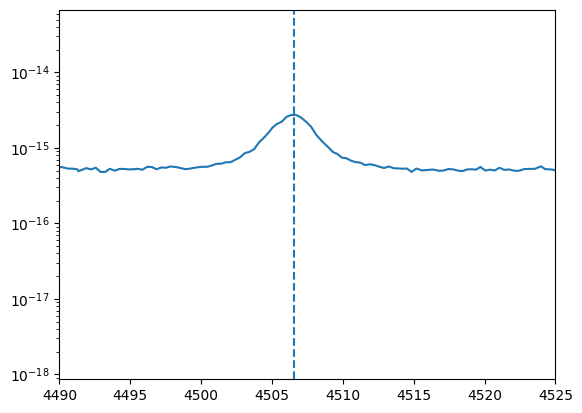

In [3]:
plt.plot(wave, flux)
plt.xlim(4490, 4525)
plt.axvline((1 + z_BN[igal])*wave_cat['Hd'], ls='--')
plt.yscale('log')

In [4]:
#texPlot('on')
#plt.plot(oiii_4363.wavelength, oiii_4363.flux/1e-17, color='black', label='spectrum')
#plt.plot(oiii_4363.wavelength, oiii_4363.noise/1e-17, ls=':', color='red', label='error')
#plt.axvline((1 + z_BN[igal])*wave_cat['[OIII]4363'], ls='--', color='green')
#plt.axvline((1 + z_BN[igal])*wave_cat['Hg'], ls='--', color='green')
#plt.xlim(4750, 4830)
#plt.ylim(0, 1.5e-15/1e-17)
#plt.text(s='[OIII]4363', x=(1 + z_BN[igal])*wave_cat['[OIII]4363'], y=1.55e-15/1e-17, rotation=30, fontsize=15, color='green')
#plt.text(s='H$\gamma$', x=(1 + z_BN[igal])*wave_cat['Hg'], y=1.55e-15/1e-17, rotation=30, fontsize=15, color='green')
#plt.xlabel('Observed $\lambda$ ($\AA$)', fontsize=15)
#plt.ylabel('Flux (10$^{-17}$ erg / cm$^{2}$ / s / $\AA$)', fontsize=15)
#plt.text(s='J0021+0052', x=4810, y=10, fontsize=15)
#plt.legend(frameon=True, fancybox=False, framealpha=1, edgecolor='black')
#plt.savefig('/home/benjamin/Documents/analogs/results/metals/OIII4363_ex.pdf', dpi=300,
#           facecolor='white', bbox_inches='tight')

In [5]:
#texPlot('on')
#plt.plot(oii_7320.wavelength, oii_7320.flux/1e-17, color='black', label='spectrum')
#plt.plot(oii_7320.wavelength, oii_7320.noise/1e-17, ls=':', color='red', label='error')
#plt.axvline((1 + z_BN[igal])*wave_cat['[OII]7319'], ls='--', color='green')
#plt.axvline((1 + z_BN[igal])*wave_cat['[OII]7330'], ls='--', color='green')
#plt.xlim(8000, 8100)
#plt.ylim(0, 50)
#plt.text(s='[OII]7320', x=(1 + z_BN[igal])*wave_cat['[OII]7319'], y=52, rotation=30, fontsize=15, color='green')
#plt.text(s='[OII]7331', x=(1 + z_BN[igal])*wave_cat['[OII]7330'], y=52, rotation=30, fontsize=15, color='green')
#plt.xlabel('Observed $\lambda$ ($\AA$)', fontsize=15)
#plt.ylabel('Flux (10$^{-17}$ erg / cm$^{2}$ / s / $\AA$)', fontsize=15)
#plt.text(s='J0021+0052', x=8075, y=3, fontsize=15)
#plt.legend(frameon=True, fancybox=False, framealpha=1, edgecolor='black')
#plt.savefig('/home/benjamin/Documents/analogs/results/metals/OII7320_ex.pdf', dpi=300,
#           facecolor='white', bbox_inches='tight')

---------

# Two component model fit for [OIII] 4959

## [OIII]4959

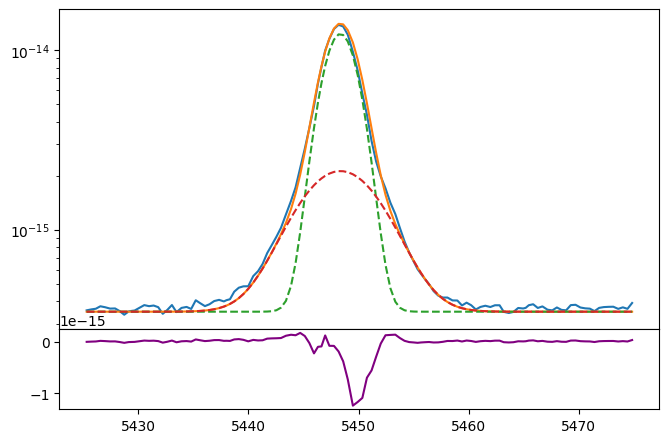

In [6]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 35e-17

oiiib_nar = gaussian(oiii_4959.wavelength, 4500e-17, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.5)
oiiib_brd = gaussian(oiii_4959.wavelength, 1600e-17, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=3.6)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [7]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z_nar', value=z_BN[igal])
params_oiii_4959.add('z_brd', value=z_BN[igal])
params_oiii_4959.add('sigma_nar', value=1.5, min=0.)
params_oiii_4959.add('sigma_brd', value=3.6, min=0.)
params_oiii_4959.add('Oiiib_nar', value=4500e-17, min=0.)
params_oiii_4959.add('Oiiib_brd', value=1600e-17, min=0.)
params_oiii_4959.add('bkg', value=35e-17, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z_nar = params_oiii_4959['z_nar']
    z_brd = params_oiii_4959['z_brd']
    sigma_nar = params_oiii_4959['sigma_nar']
    sigma_brd = params_oiii_4959['sigma_brd']
    oiiib_nar = params_oiii_4959['Oiiib_nar']
    oiiib_brd = params_oiii_4959['Oiiib_brd']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [8]:
np.random.seed(21)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 134.41it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 6 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 33.26731302  57.43484089 146.07777983 169.69835989 159.96171546
 165.16319463 145.43672894]


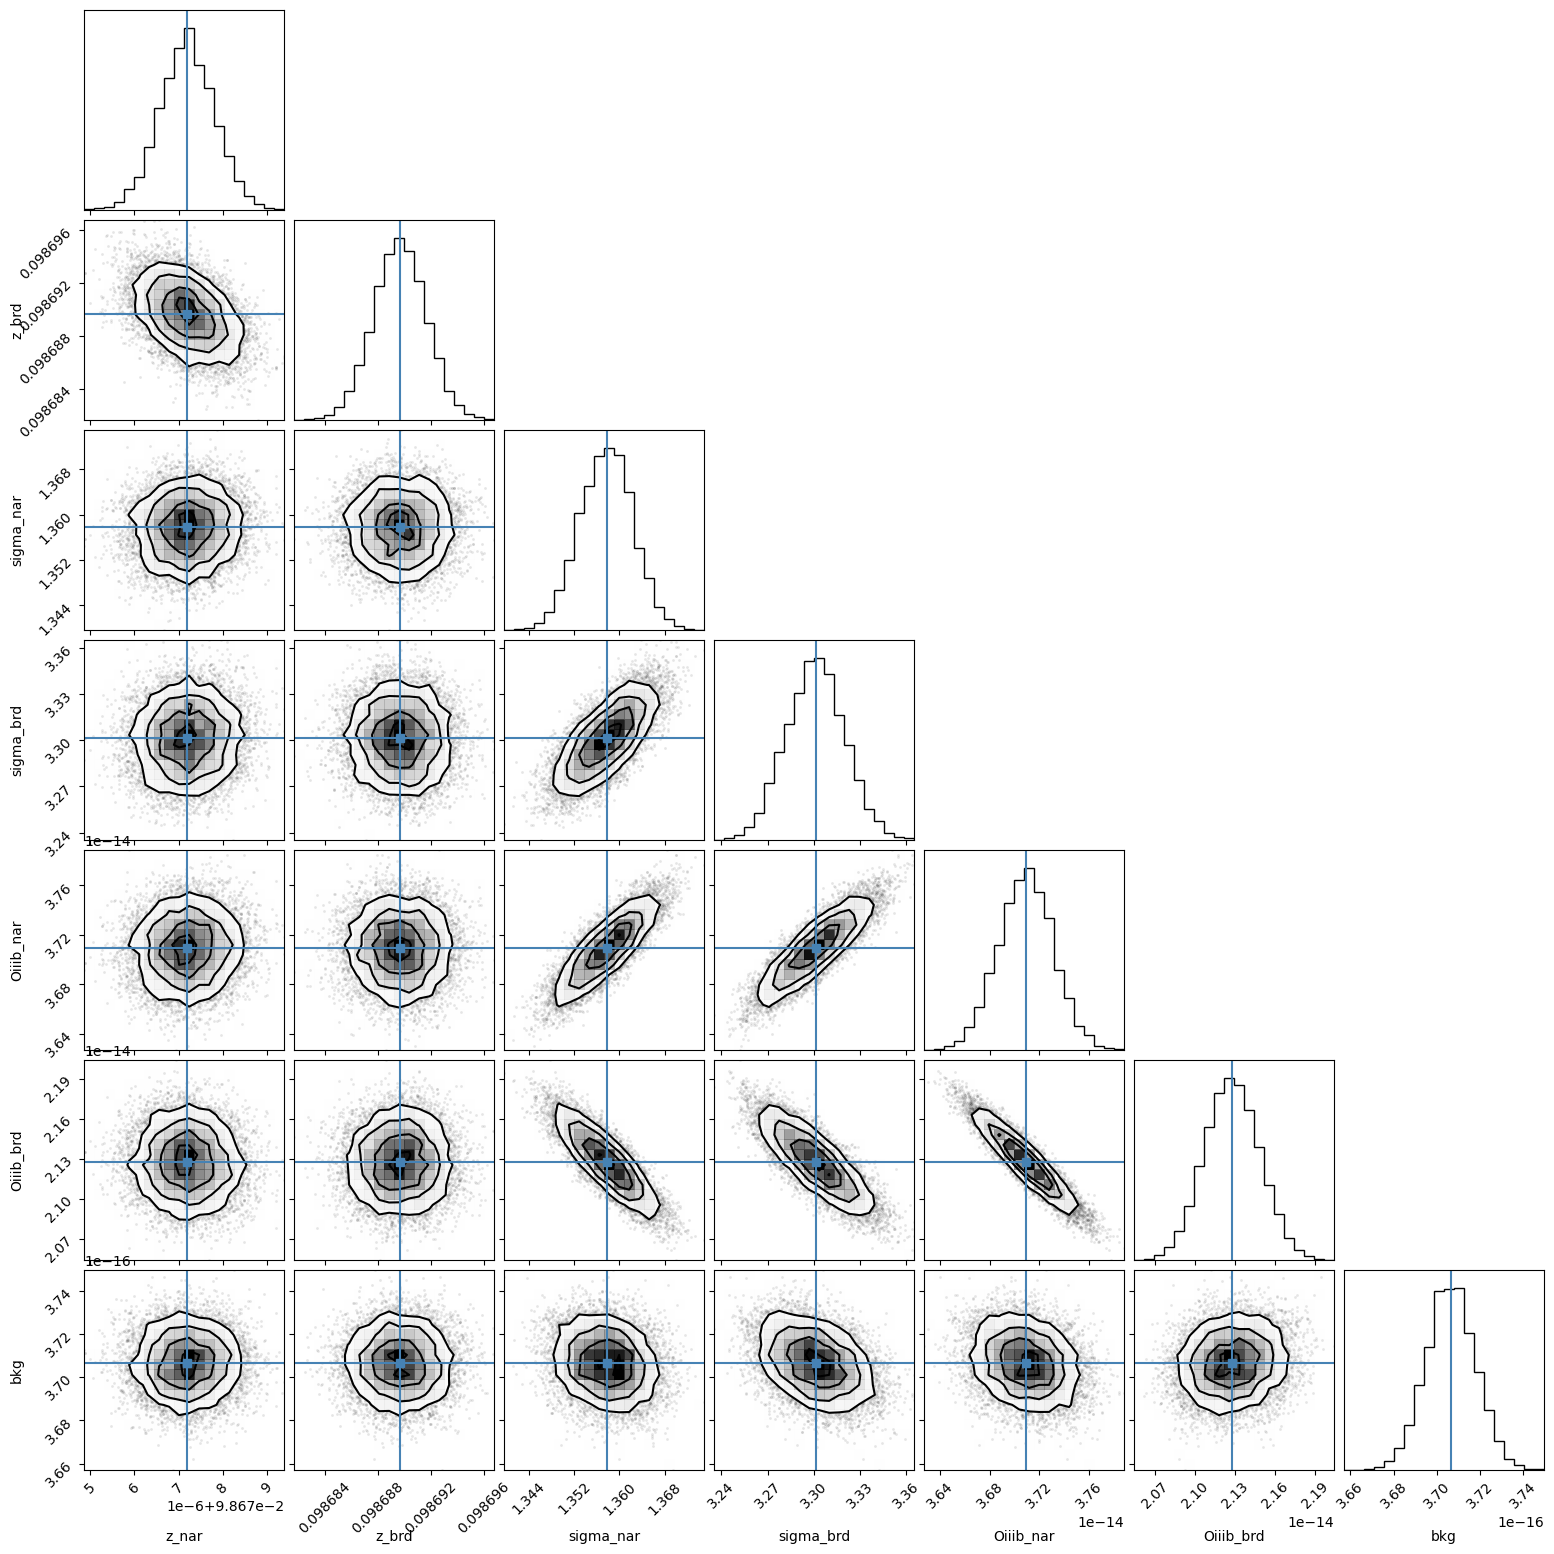

In [9]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names,
             truths=list(out_oiii_4959.params.valuesdict().values()));
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [10]:
out_oiii_4959

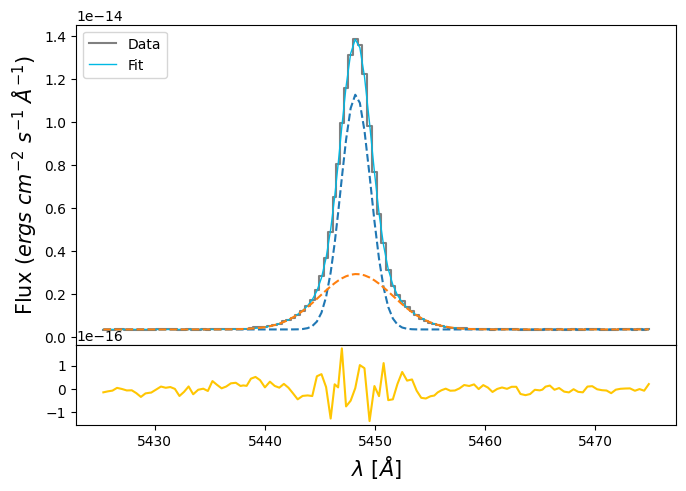

In [11]:
oiiib_nar_flux = out_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_brd_flux = out_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out_oiii_4959.flatchain.Oiiib_brd.std()

bkg_oiii_4959 = out_oiii_4959.flatchain.bkg.mean()
bkg_oiii_4959_std = out_oiii_4959.flatchain.bkg.std()

z_nar_oiii_4959 = out_oiii_4959.flatchain.z_nar.mean()
z_nar_oiii_4959_std = out_oiii_4959.flatchain.z_nar.std()

z_brd_oiii_4959 = out_oiii_4959.flatchain.z_brd.mean()
z_brd_oiii_4959_std = out_oiii_4959.flatchain.z_brd.std()

sigma_nar_oiii_4959 = out_oiii_4959.flatchain.sigma_nar.mean()
sigma_nar_oiii_4959_std = out_oiii_4959.flatchain.sigma_nar.std()

sigma_brd_oiii_4959 = out_oiii_4959.flatchain.sigma_brd.mean()
sigma_brd_oiii_4959_std = out_oiii_4959.flatchain.sigma_brd.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)

#ls_4959 = (wave_cat['[OIII]4959'] * (1 + z_nar_oiii_4959)) + (3 * sigma_brd_oiii_4959)
#li_4959 = (wave_cat['[OIII]4959'] * (1 + z_nar_oiii_4959)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_4959, ls='--', color='gray', lw=0.8)
#ax.axvline(li_4959, ls='--', color='gray', lw=0.8)

#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [39]:
# EW
EW_OIII_4959_nar = ufloat(oiiib_nar_flux, oiiib_nar_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959_brd = ufloat(oiiib_brd_flux, oiiib_brd_std) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)
EW_OIII_4959 = (ufloat(oiiib_nar_flux, oiiib_nar_std) + ufloat(oiiib_brd_flux, oiiib_brd_std)) / ufloat(bkg_oiii_4959, bkg_oiii_4959_std)

# FWHM
FWHM_4959_nar = FWHM(ufloat(sigma_nar_oiii_4959, sigma_nar_oiii_4959_std),  wave_cat['[OIII]4959']*(1 + ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std)))
FWHM_4959_brd = FWHM(ufloat(sigma_brd_oiii_4959, sigma_brd_oiii_4959_std),  wave_cat['[OIII]4959']*(1 + ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std)))

# velocity shift
dV_4959 = dV(ufloat(z_brd_oiii_4959, z_brd_oiii_4959_std),
             ufloat(z_nar_oiii_4959, z_nar_oiii_4959_std))

# Ratio to fix velocity shifts between components
z_ratio = z_brd_oiii_4959 / z_nar_oiii_4959

# Ratio to distribute the flux between components in no detection
brd_to_nar = oiiib_brd_flux / oiiib_nar_flux

# Dispersion for the whole spectra
dLam = (np.max(wave) - np.min(wave)) / len(wave)

---------

# Two component model fit for H$\alpha$

## [NII]6548 + H$\alpha$ + [NII]6584

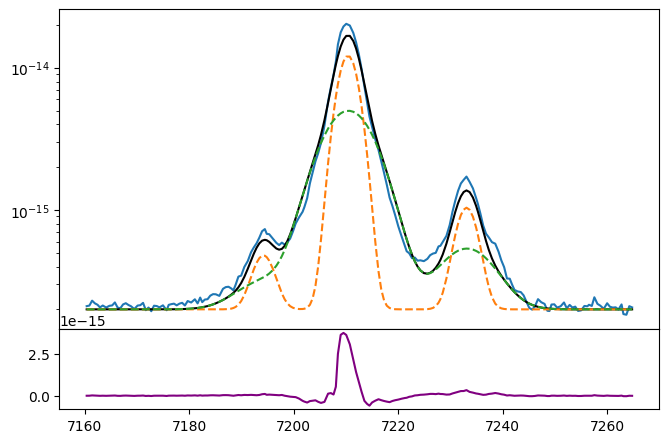

In [14]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(ha_nii.wavelength, ha_nii.flux)
bkg = 2e-16

ha_nar = gaussian(ha_nii.wavelength, 6e-14, wave_cat['Ha'], z=z_nar_oiii_4959, sigma=2)
ha_brd = gaussian(ha_nii.wavelength, 6e-14, wave_cat['Ha'], z=z_brd_oiii_4959, sigma=5)

niib_nar = gaussian(ha_nii.wavelength, 1.4e-15, wave_cat['[NII]6548'], z=z_nar_oiii_4959, sigma=2)
niib_brd = gaussian(ha_nii.wavelength, 1.4e-15, wave_cat['[NII]6548'], z=z_brd_oiii_4959, sigma=5)

niia_nar = gaussian(ha_nii.wavelength, 4.2e-15, wave_cat['[NII]6584'], z=z_nar_oiii_4959, sigma=2)
niia_brd = gaussian(ha_nii.wavelength, 4.2e-15, wave_cat['[NII]6584'], z=z_brd_oiii_4959, sigma=5)

ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

ax.plot(ha_nii.wavelength, bkg + niib + ha + niia, color='black')
ax.plot(ha_nii.wavelength, bkg + niib_nar + ha_nar + niia_nar, ls='--')
ax.plot(ha_nii.wavelength, bkg + niib_brd + ha_brd + niia_brd, ls='--')
ax1.plot(ha_nii.wavelength, ha_nii.flux - bkg - niib - ha - niia, color='purple')

#ax.axvline(7175)
#ax.axvline(7247)
ax.set_yscale('log')

In [17]:
params_ha_nii = Parameters()
params_ha_nii.add('z_nar', value=z_nar_oiii_4959, vary=True)
params_ha_nii.add('z_brd', value=z_brd_oiii_4959, vary=True)
params_ha_nii.add('sigma_nar', value=2, min=0.)
params_ha_nii.add('sigma_brd', value=5, min=0.)
params_ha_nii.add('Ha_nar', value=6e-14, min=0.)
params_ha_nii.add('Ha_brd', value=6e-14, min=0.)
params_ha_nii.add('Niia_nar', value=4.2e-15, min=0.)
params_ha_nii.add('Niia_brd', value=4.2e-15, min=0.)
params_ha_nii.add('Niib_to_niia', value=1/3, min=0., max=1.)
params_ha_nii.add('bkg', value=2e-16, vary=True)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z_nar = params_ha_nii['z_nar']
    z_brd = params_ha_nii['z_brd']
    sigma_nar = params_ha_nii['sigma_nar']
    sigma_brd = params_ha_nii['sigma_brd']
    ha_nar = params_ha_nii['Ha_nar']
    ha_brd = params_ha_nii['Ha_brd']
    niia_nar = params_ha_nii['Niia_nar']
    niia_brd = params_ha_nii['Niia_brd']
    niib_nar = params_ha_nii['Niia_nar']*params_ha_nii['Niib_to_niia']
    niib_brd = params_ha_nii['Niia_brd']*params_ha_nii['Niib_to_niia']
    bkg = params_ha_nii['bkg']
    
    x = ha_nii.wavelength
    
    model_ha = gaussian(x, ha_nar, wave_cat['Ha'], z_nar, sigma_nar) \
             + gaussian(x, ha_brd, wave_cat['Ha'], z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, wave_cat['[NII]6584'], z_nar, sigma_nar) \
               + gaussian(x, niia_brd, wave_cat['[NII]6584'], z_brd, sigma_brd)
    
    model_niib = gaussian(x, niib_nar, wave_cat['[NII]6548'], z_nar, sigma_nar) \
               + gaussian(x, niib_brd, wave_cat['[NII]6548'], z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    
    return (model + bkg - ha_nii.flux) / ha_nii.noise

In [18]:
np.random.seed(21)
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:34<00:00, 73.38it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 90.41047582  65.97602319 114.92052107 141.73192722  49.92108616
  47.71278495 280.94037894 305.40211076 254.12500316  96.8141648 ]


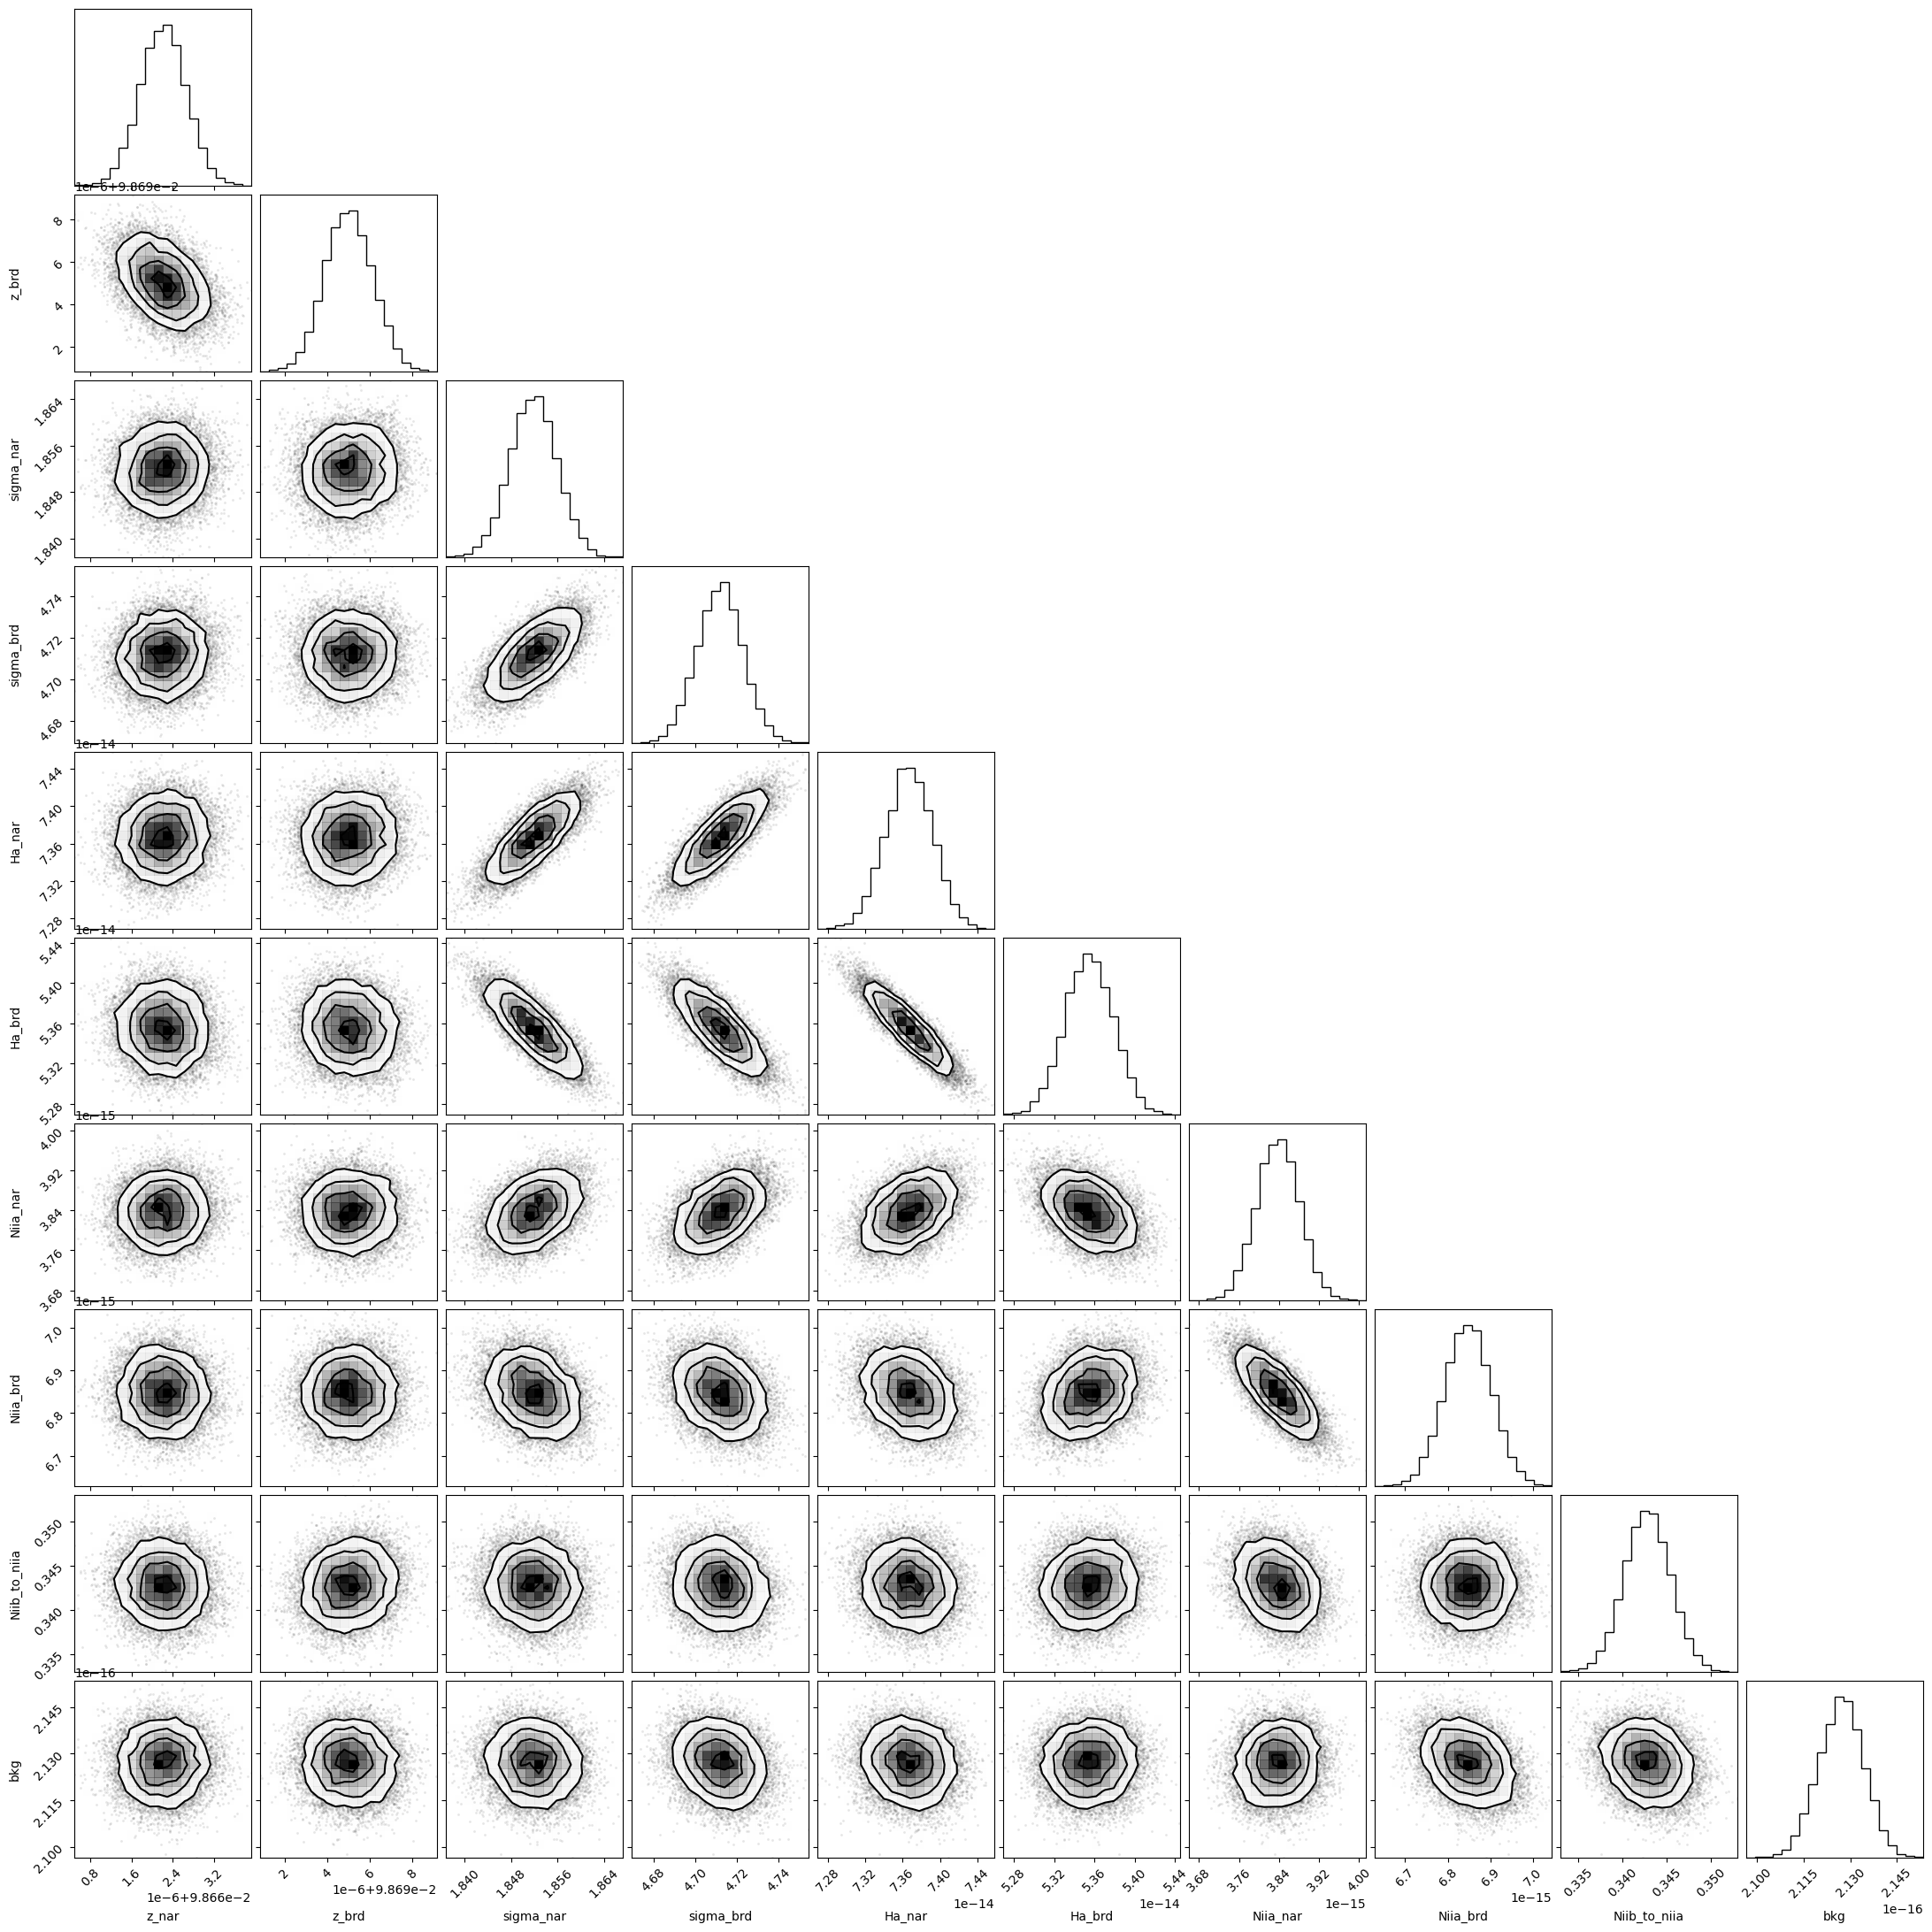

In [19]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [20]:
out_ha_nii

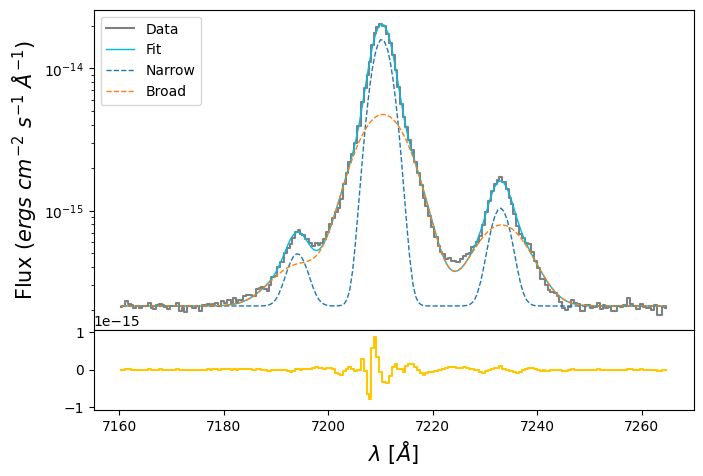

In [22]:
ha_nar_flux = out_ha_nii.flatchain.Ha_nar.mean()
ha_nar_std = out_ha_nii.flatchain.Ha_nar.std()

ha_brd_flux = out_ha_nii.flatchain.Ha_brd.mean()
ha_brd_std = out_ha_nii.flatchain.Ha_brd.std()

niia_nar_flux = out_ha_nii.flatchain.Niia_nar.mean()
niia_nar_std = out_ha_nii.flatchain.Niia_nar.std()

niia_brd_flux = out_ha_nii.flatchain.Niia_brd.mean()
niia_brd_std = out_ha_nii.flatchain.Niia_brd.std()

niib_nar_flux = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_nar_std = (niia_nar_flux * out_ha_nii.flatchain.Niib_to_niia).std()

niib_brd_flux = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).mean()
niib_brd_std = (niia_brd_flux * out_ha_nii.flatchain.Niib_to_niia).std()

z_nar_ha_nii = out_ha_nii.flatchain.z_nar.mean()
z_nar_ha_nii_std = out_ha_nii.flatchain.z_nar.std()

z_brd_ha_nii = out_ha_nii.flatchain.z_brd.mean()
z_brd_ha_nii_std = out_ha_nii.flatchain.z_brd.std()

sigma_nar_ha_nii = out_ha_nii.flatchain.sigma_nar.mean()
sigma_nar_ha_nii_std = out_ha_nii.flatchain.sigma_nar.std()

sigma_brd_ha_nii = out_ha_nii.flatchain.sigma_brd.mean()
sigma_brd_ha_nii_std = out_ha_nii.flatchain.sigma_brd.std()

bkg_ha_nii = out_ha_nii.flatchain.bkg.mean()
bkg_ha_nii_std = out_ha_nii.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(ha_nii.wavelength, ha_nii.flux,
            color='gray', label='Data', where='mid')

ha_nar = gaussian(ha_nii.wavelength, ha_nar_flux, wave_cat['Ha'], z_nar_ha_nii, sigma_nar_ha_nii)
ha_brd = gaussian(ha_nii.wavelength, ha_brd_flux, wave_cat['Ha'], z_brd_ha_nii, sigma_brd_ha_nii)

niia_nar = gaussian(ha_nii.wavelength, niia_nar_flux, wave_cat['[NII]6584'], z_nar_ha_nii, sigma_nar_ha_nii)
niia_brd = gaussian(ha_nii.wavelength, niia_brd_flux, wave_cat['[NII]6584'], z_brd_ha_nii, sigma_brd_ha_nii)

niib_nar = gaussian(ha_nii.wavelength, niib_nar_flux, wave_cat['[NII]6548'], z_nar_ha_nii, sigma_nar_ha_nii)
niib_brd = gaussian(ha_nii.wavelength, niib_brd_flux, wave_cat['[NII]6548'], z_brd_ha_nii, sigma_brd_ha_nii)

niia = niia_nar + niia_brd
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia + ha + niib,
        lw=1, color=c[0], label='Fit')

ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_nar + ha_nar + niib_nar,
        ls='--', lw=1, label='Narrow')
ax.plot(ha_nii.wavelength, bkg_ha_nii + niia_brd + ha_brd + niib_brd,
        ls='--', lw=1, label='Broad')

ax1.step(ha_nii.wavelength, ha_nii.flux - bkg_ha_nii - niia - ha - niib,
         color=c[3], where='mid')
ax1.set_ylim(-5*bkg_ha_nii, 5*bkg_ha_nii)
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')

#ls_niib = (wave_cat['[NII]6548'] * (1 + z_ha_nii)) + (3 * sigma_brd_oiii_4959)
#li_niib = (wave_cat['[NII]6548'] * (1 + z_ha_nii)) - (3 * sigma_brd_oiii_4959)

#ls_ha = (wave_cat['Ha'] * (1 + z_ha_nii)) + (3 * sigma_brd_oiii_4959)
#li_ha = (wave_cat['Ha'] * (1 + z_ha_nii)) - (3 * sigma_brd_oiii_4959)

#ls_niia = (wave_cat['[NII]6584'] * (1 + z_ha_nii)) + (3 * sigma_brd_oiii_4959)
#li_niia = (wave_cat['[NII]6584'] * (1 + z_ha_nii)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_niib, ls='--', color='gray', lw=0.8)
#ax.axvline(li_niib, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_ha, ls='--', color='gray', lw=0.8)
#ax.axvline(li_ha, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_niia, ls='--', color='gray', lw=0.8)
#ax.axvline(li_niia, ls='--', color='gray', lw=0.8)


#ax.text(x=7008, y=1.5e-13, s=r'[NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584',
#       fontsize=15)
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [23]:
# EW
EW_Ha_nar = ufloat(ha_nar_flux, ha_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha_brd = ufloat(ha_brd_flux, ha_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_Ha = (ufloat(ha_nar_flux, ha_nar_std) + ufloat(ha_brd_flux, ha_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6584_nar = ufloat(niia_nar_flux, niia_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584_brd = ufloat(niia_brd_flux, niia_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6584 = (ufloat(niia_nar_flux, niia_nar_std) + ufloat(niia_brd_flux, niia_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

EW_NII_6548_nar = ufloat(niib_nar_flux, niib_nar_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548_brd = ufloat(niib_brd_flux, niib_brd_std) / ufloat(bkg_ha_nii, bkg_ha_nii_std)
EW_NII_6548 = (ufloat(niib_nar_flux, niib_nar_std) + ufloat(niib_brd_flux, niib_brd_std)) / ufloat(bkg_ha_nii, bkg_ha_nii_std)

In [38]:
# velocity shift
dV_ha = dV(ufloat(z_brd_ha_nii, z_brd_ha_nii_std),
             ufloat(z_nar_ha_nii, z_nar_ha_nii_std))

# Ratio to fix velocity shifts between components
z_ratio_ha = z_brd_ha_nii / z_nar_ha_nii

## [OII]7319 + [OII]7330

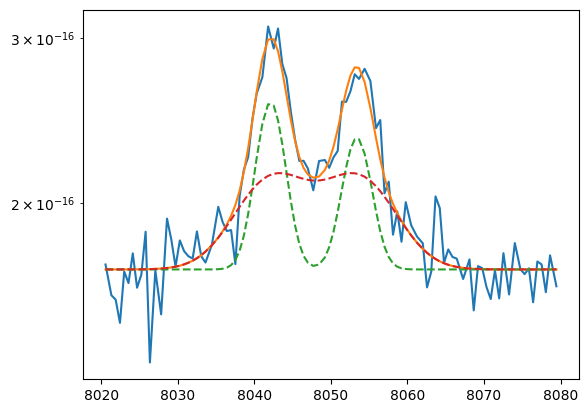

In [32]:
# Search for good initial guess

plt.plot(oii_7320.wavelength, oii_7320.flux)

oiia_nar = gaussian(oii_7320.wavelength, 3e-16, wave_cat['[OII]7330'], z=z_nar_ha_nii, sigma=sigma_nar_ha_nii)
oiia_brd = gaussian(oii_7320.wavelength, 5e-16, wave_cat['[OII]7330'], z=z_brd_ha_nii, sigma=sigma_brd_ha_nii)

oiib_nar = gaussian(oii_7320.wavelength, 4e-16, wave_cat['[OII]7319'], z=z_nar_ha_nii, sigma=sigma_nar_ha_nii)
oiib_brd = gaussian(oii_7320.wavelength, 5e-16, wave_cat['[OII]7319'], z=z_brd_ha_nii, sigma=sigma_brd_ha_nii)

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd
bkg = 1.7e-16

plt.plot(oii_7320.wavelength, bkg + oiib + oiia)
plt.plot(oii_7320.wavelength, bkg + oiib_nar + oiia_nar, ls='--')
plt.plot(oii_7320.wavelength, bkg + oiib_brd + oiia_brd, ls='--')

plt.yscale('log')

In [42]:
params_oii_7320 = Parameters()

params_oii_7320.add('z_nar', value=z_nar_ha_nii, vary=True)
params_oii_7320.add('z_ratio', value=z_ratio_ha, vary=False)
params_oii_7320.add('sigma_nar', value=sigma_nar_ha_nii, vary=False)
params_oii_7320.add('sigma_brd', value=sigma_brd_ha_nii, vary=False)
params_oii_7320.add('Oiia_nar', value=3.0e-16, min=0.)
params_oii_7320.add('Oiia_brd', value=5.0e-16, min=0.)
params_oii_7320.add('Oiib_nar', value=4.0e-16, min=0.)
params_oii_7320.add('Oiib_brd', value=5.0e-16, min=0.)
params_oii_7320.add('bkg', value=1.7e-16, min=0.)

def residual_oii_7320(params_oii_7320, x, data, uncertainty):
    
    z_nar = params_oii_7320['z_nar']
    z_brd = params_oii_7320['z_nar'] * params_oii_7320['z_ratio']
    sigma_nar = params_oii_7320['sigma_nar']
    sigma_brd = params_oii_7320['sigma_brd']
    oiia_nar_flux = params_oii_7320['Oiia_nar']
    oiia_brd_flux = params_oii_7320['Oiia_brd']
    oiib_nar_flux = params_oii_7320['Oiib_nar']
    oiib_brd_flux = params_oii_7320['Oiib_brd']
    bkg = params_oii_7320['bkg']
    
    x = oii_7320.wavelength
    model_oiia = gaussian(x, oiia_nar_flux, wave_cat['[OII]7330'], z_nar, sigma_nar) + \
                 gaussian(x, oiia_brd_flux, wave_cat['[OII]7330'], z_brd, sigma_brd)
    model_oiib = gaussian(x, oiib_nar_flux, wave_cat['[OII]7319'], z_nar, sigma_nar) + \
                 gaussian(x, oiib_brd_flux, wave_cat['[OII]7319'], z_brd, sigma_brd)
    model = model_oiia + model_oiib
    return (model + bkg - oii_7320.flux) / oii_7320.noise

In [43]:
np.random.seed(21)
out_oii_7320 = minimize(residual_oii_7320, params_oii_7320, args=(1, 1, 1),
                         method='emcee', burn=1000, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:24<00:00, 100.28it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [52.09861054 55.18705212 55.65778901 50.0025156  48.65678553 56.43534927]


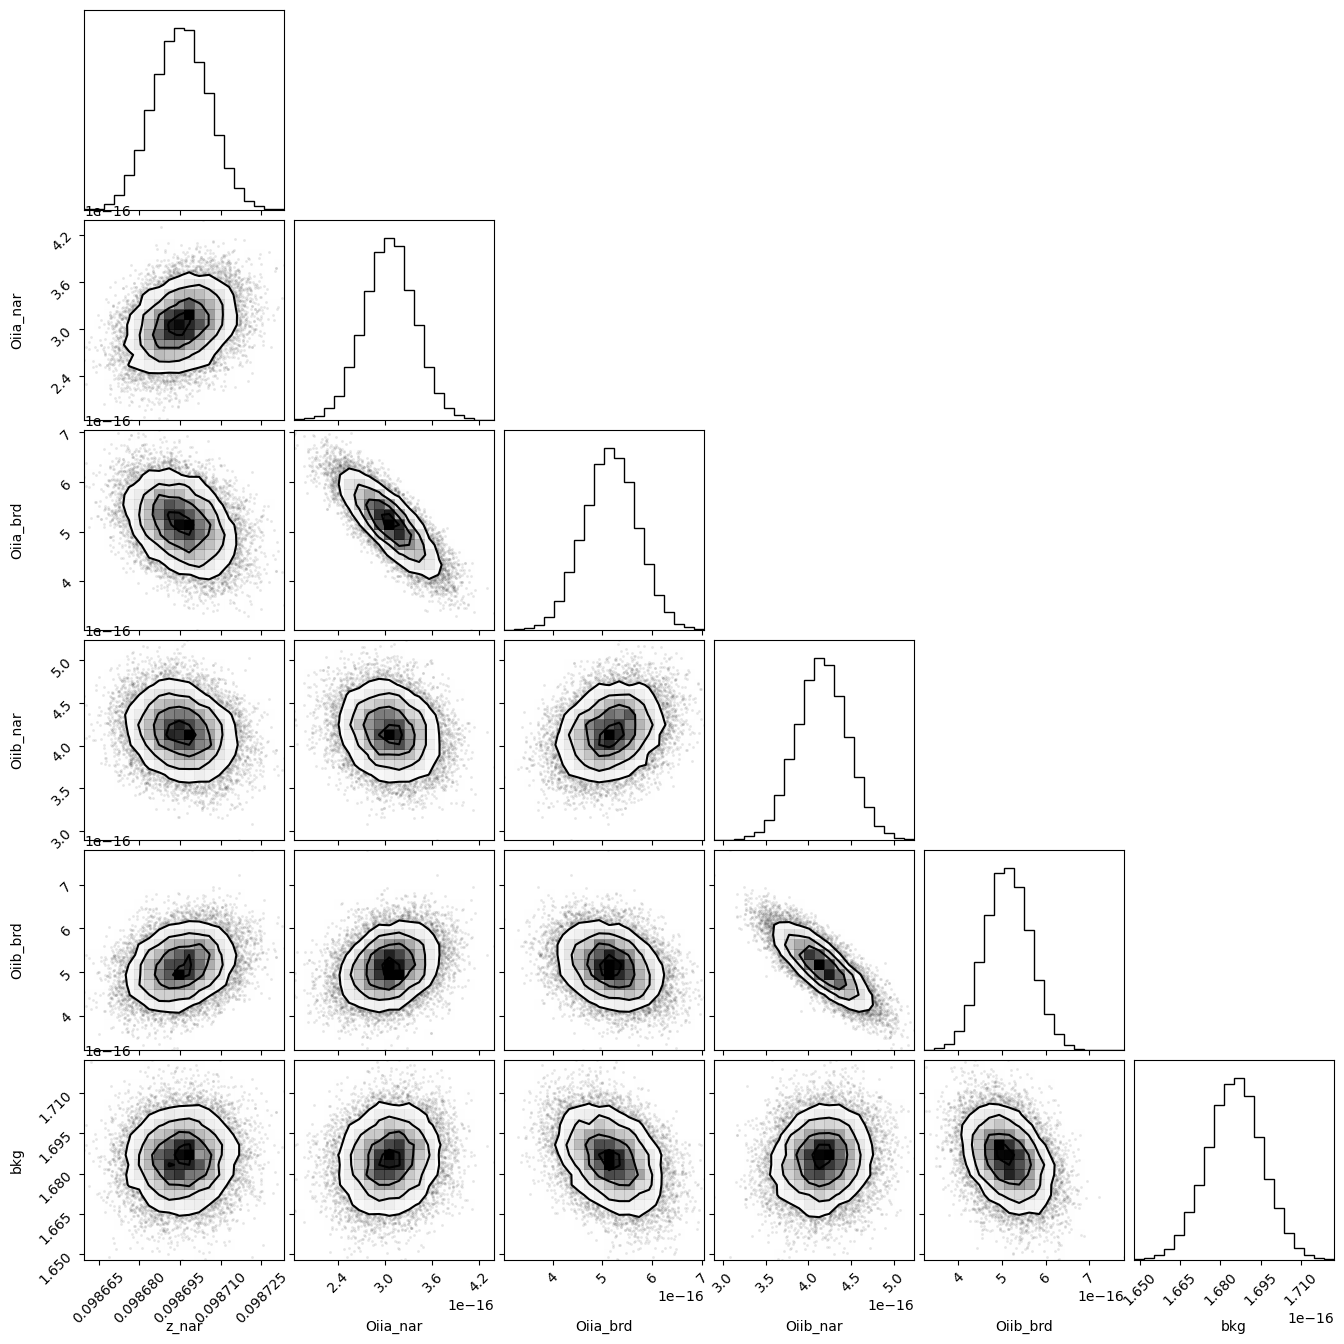

In [44]:
corner.corner(out_oii_7320.flatchain, labels=out_oii_7320.var_names);

In [46]:
out_oii_7320

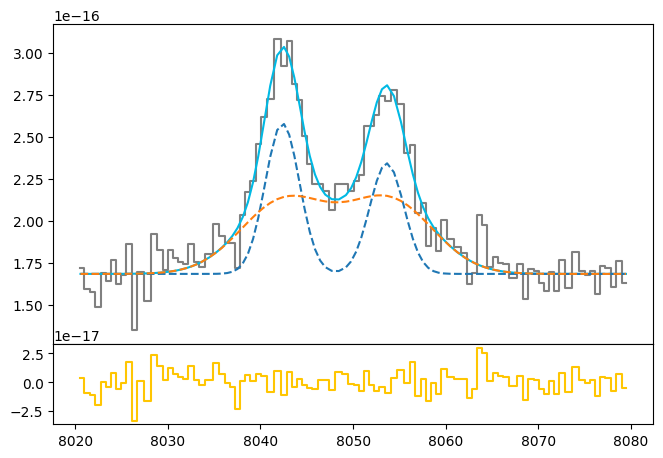

In [47]:
oiia_nar_flux = out_oii_7320.flatchain.Oiia_nar.mean()
oiia_nar_std = out_oii_7320.flatchain.Oiia_nar.std()

oiia_brd_flux = out_oii_7320.flatchain.Oiia_brd.mean()
oiia_brd_std = out_oii_7320.flatchain.Oiia_brd.std()

oiib_nar_flux = out_oii_7320.flatchain.Oiib_nar.mean()
oiib_nar_std = out_oii_7320.flatchain.Oiib_nar.std()

oiib_brd_flux = out_oii_7320.flatchain.Oiib_brd.mean()
oiib_brd_std = out_oii_7320.flatchain.Oiib_brd.std()

z_oii_7320 = out_oii_7320.flatchain.z_nar.mean()
z_oii_7320_std = out_oii_7320.flatchain.z_nar.std()

bkg_oii_7320 = out_oii_7320.flatchain.bkg.mean()
bkg_oii_7320_std = out_oii_7320.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_7320.wavelength, oii_7320.flux, color='gray', label='Data', where='mid')

oiia_nar = gaussian(oii_7320.wavelength, oiia_nar_flux, wave_cat['[OII]7330'], z_oii_7320, sigma_nar_ha_nii)
oiib_nar = gaussian(oii_7320.wavelength, oiib_nar_flux, wave_cat['[OII]7319'], z_oii_7320, sigma_nar_ha_nii)

oiia_brd = gaussian(oii_7320.wavelength, oiia_brd_flux, wave_cat['[OII]7330'], z_oii_7320 * z_ratio_ha, sigma_brd_ha_nii)
oiib_brd = gaussian(oii_7320.wavelength, oiib_brd_flux, wave_cat['[OII]7319'], z_oii_7320 * z_ratio_ha, sigma_brd_ha_nii)

oiia = oiia_nar + oiia_brd
oiib = oiib_nar + oiib_brd

ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia + oiib, color=c[0])
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_nar + oiib_nar, ls='--')
ax.plot(oii_7320.wavelength, bkg_oii_7320 + oiia_brd + oiib_brd, ls='--')
#plt.yscale('log')
ax1.step(oii_7320.wavelength, oii_7320.flux - bkg_oii_7320 - oiia - oiib, color=c[3], where='mid')


#ls_oiib = (wave_cat['[OII]7319'] * (1 + z_oii_7320)) + (3 * sigma_brd_oiii_4959)
#li_oiib = (wave_cat['[OII]7319'] * (1 + z_oii_7320)) - (3 * sigma_brd_oiii_4959)

#ls_oiia = (wave_cat['[OII]7330'] * (1 + z_oii_7320)) + (3 * sigma_brd_oiii_4959)
#li_oiia = (wave_cat['[OII]7330'] * (1 + z_oii_7320)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_oiib, ls='--', color='gray', lw=0.8)
#ax.axvline(li_oiib, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_oiia, ls='--', color='gray', lw=0.8)
#ax.axvline(li_oiia, ls='--', color='gray', lw=0.8)

In [48]:
# EW
EW_OII_7330_nar = ufloat(oiia_nar_flux, oiia_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330_brd = ufloat(oiia_brd_flux, oiia_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7330 = (ufloat(oiia_nar_flux, oiia_nar_std) + ufloat(oiia_brd_flux, oiia_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

EW_OII_7319_nar = ufloat(oiib_nar_flux, oiib_nar_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319_brd = ufloat(oiib_brd_flux, oiib_brd_std) / ufloat(bkg_oii_7320, bkg_oii_7320_std)
EW_OII_7319 = (ufloat(oiib_nar_flux, oiib_nar_std) + ufloat(oiib_brd_flux, oiib_brd_std)) / ufloat(bkg_oii_7320, bkg_oii_7320_std)

## [OII]3726 + [OII]3729

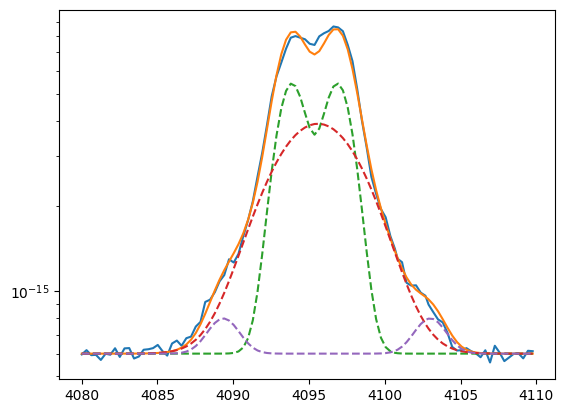

In [87]:
# Search for good initial guess

plt.plot(oii_3727.wavelength, oii_3727.flux)

h13 = gaussian(oii_3727.wavelength, 5e-16, wave_cat['H13'], z=z_nar_ha_nii+0.00005, sigma=1)

oiic_nar = gaussian(oii_3727.wavelength, 1.2e-14, wave_cat['[OII]3729'], z=z_nar_ha_nii+0.00005, sigma=1)
oiic_brd = gaussian(oii_3727.wavelength, 1.3e-14, wave_cat['[OII]3729'], z=z_brd_ha_nii+0.00005, sigma=2.5)

oiid_nar = gaussian(oii_3727.wavelength, 1.2e-14, wave_cat['[OII]3726'], z=z_nar_ha_nii+0.00005, sigma=1)
oiid_brd = gaussian(oii_3727.wavelength, 1.2e-14, wave_cat['[OII]3726'], z=z_brd_ha_nii+0.00005, sigma=2.5)

h14 = gaussian(oii_3727.wavelength, 0.5e-15, wave_cat['H14'], z=z_nar_ha_nii+0.00005, sigma=1)

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

bkg = 6e-16

plt.plot(oii_3727.wavelength, bkg + oiid + oiic + h13 + h14)
plt.plot(oii_3727.wavelength, bkg + oiid_nar + oiic_nar, ls='--')
plt.plot(oii_3727.wavelength, bkg + oiid_brd + oiic_brd, ls='--')
plt.plot(oii_3727.wavelength, bkg + h13 + h14, ls='--')


plt.yscale('log')

In [94]:
params_oii_3727 = Parameters()

params_oii_3727.add('z_nar', value=z_nar_ha_nii+0.00005, vary=True, min=0.)
params_oii_3727.add('z_brd', value=z_nar_ha_nii+0.00005, vary=True, min=0.)
params_oii_3727.add('sigma_nar', value=1, vary=True, min=0.)
params_oii_3727.add('sigma_brd', value=2.85, vary=True, min=0.)
params_oii_3727.add('H13', value=0.5e-15, min=0.)
params_oii_3727.add('H14', value=0.5e-15, min=0.)
params_oii_3727.add('Oiic_nar', value=1.3e-14, min=0.)
params_oii_3727.add('Oiic_brd', value=2.5e-14, min=0.)
params_oii_3727.add('Oiid_nar', value=1.1e-14, min=0.)
params_oii_3727.add('Oiid_brd', value=2.0e-14, min=0.)

params_oii_3727.add('bkg', value=6e-16, min=0.)

def residual_oii_3727(params_oii_3727, x, data, uncertainty):
    
    z_nar = params_oii_3727['z_nar']
    z_brd = params_oii_3727['z_brd']
    sigma_nar = params_oii_3727['sigma_nar']
    sigma_brd = params_oii_3727['sigma_brd']
    
    h13_flux = params_oii_3727['H13']
    oiic_nar_flux = params_oii_3727['Oiic_nar']
    oiic_brd_flux = params_oii_3727['Oiic_brd']
    oiid_nar_flux = params_oii_3727['Oiid_nar']
    oiid_brd_flux = params_oii_3727['Oiid_brd']
    h14_flux = params_oii_3727['H14']
    bkg = params_oii_3727['bkg']
    
    x = oii_3727.wavelength
    model_h13 = gaussian(x, h13_flux, wave_cat['H13'], z_nar, sigma_nar)
    model_h14 = gaussian(x, h14_flux, wave_cat['H14'], z_nar, sigma_nar)
    model_oiic = gaussian(x, oiic_nar_flux, wave_cat['[OII]3729'], z_nar, sigma_nar) + \
                 gaussian(x, oiic_brd_flux, wave_cat['[OII]3729'], z_brd, sigma_brd)
    model_oiid = gaussian(x, oiid_nar_flux, wave_cat['[OII]3726'], z_nar, sigma_nar) + \
                 gaussian(x, oiid_brd_flux, wave_cat['[OII]3726'], z_brd, sigma_brd)
    
    model = model_h13 + model_oiic + model_oiid + model_h14
    return (model + bkg - oii_3727.flux) / oii_3727.noise

In [95]:
np.random.seed(21)
out_oii_3727 = minimize(residual_oii_3727, params_oii_3727, args=(1, 1, 1),
                         method='emcee', burn=1000, steps=2500, thin=10)

100%|███████████████████████████████████████| 2500/2500 [00:27<00:00, 90.98it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 11 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [137.60689499 249.07047705 134.20374903 103.09029062 171.7679385
 236.33898541  55.3511673  154.53150167  60.78741192 250.14434853
 103.39633547]


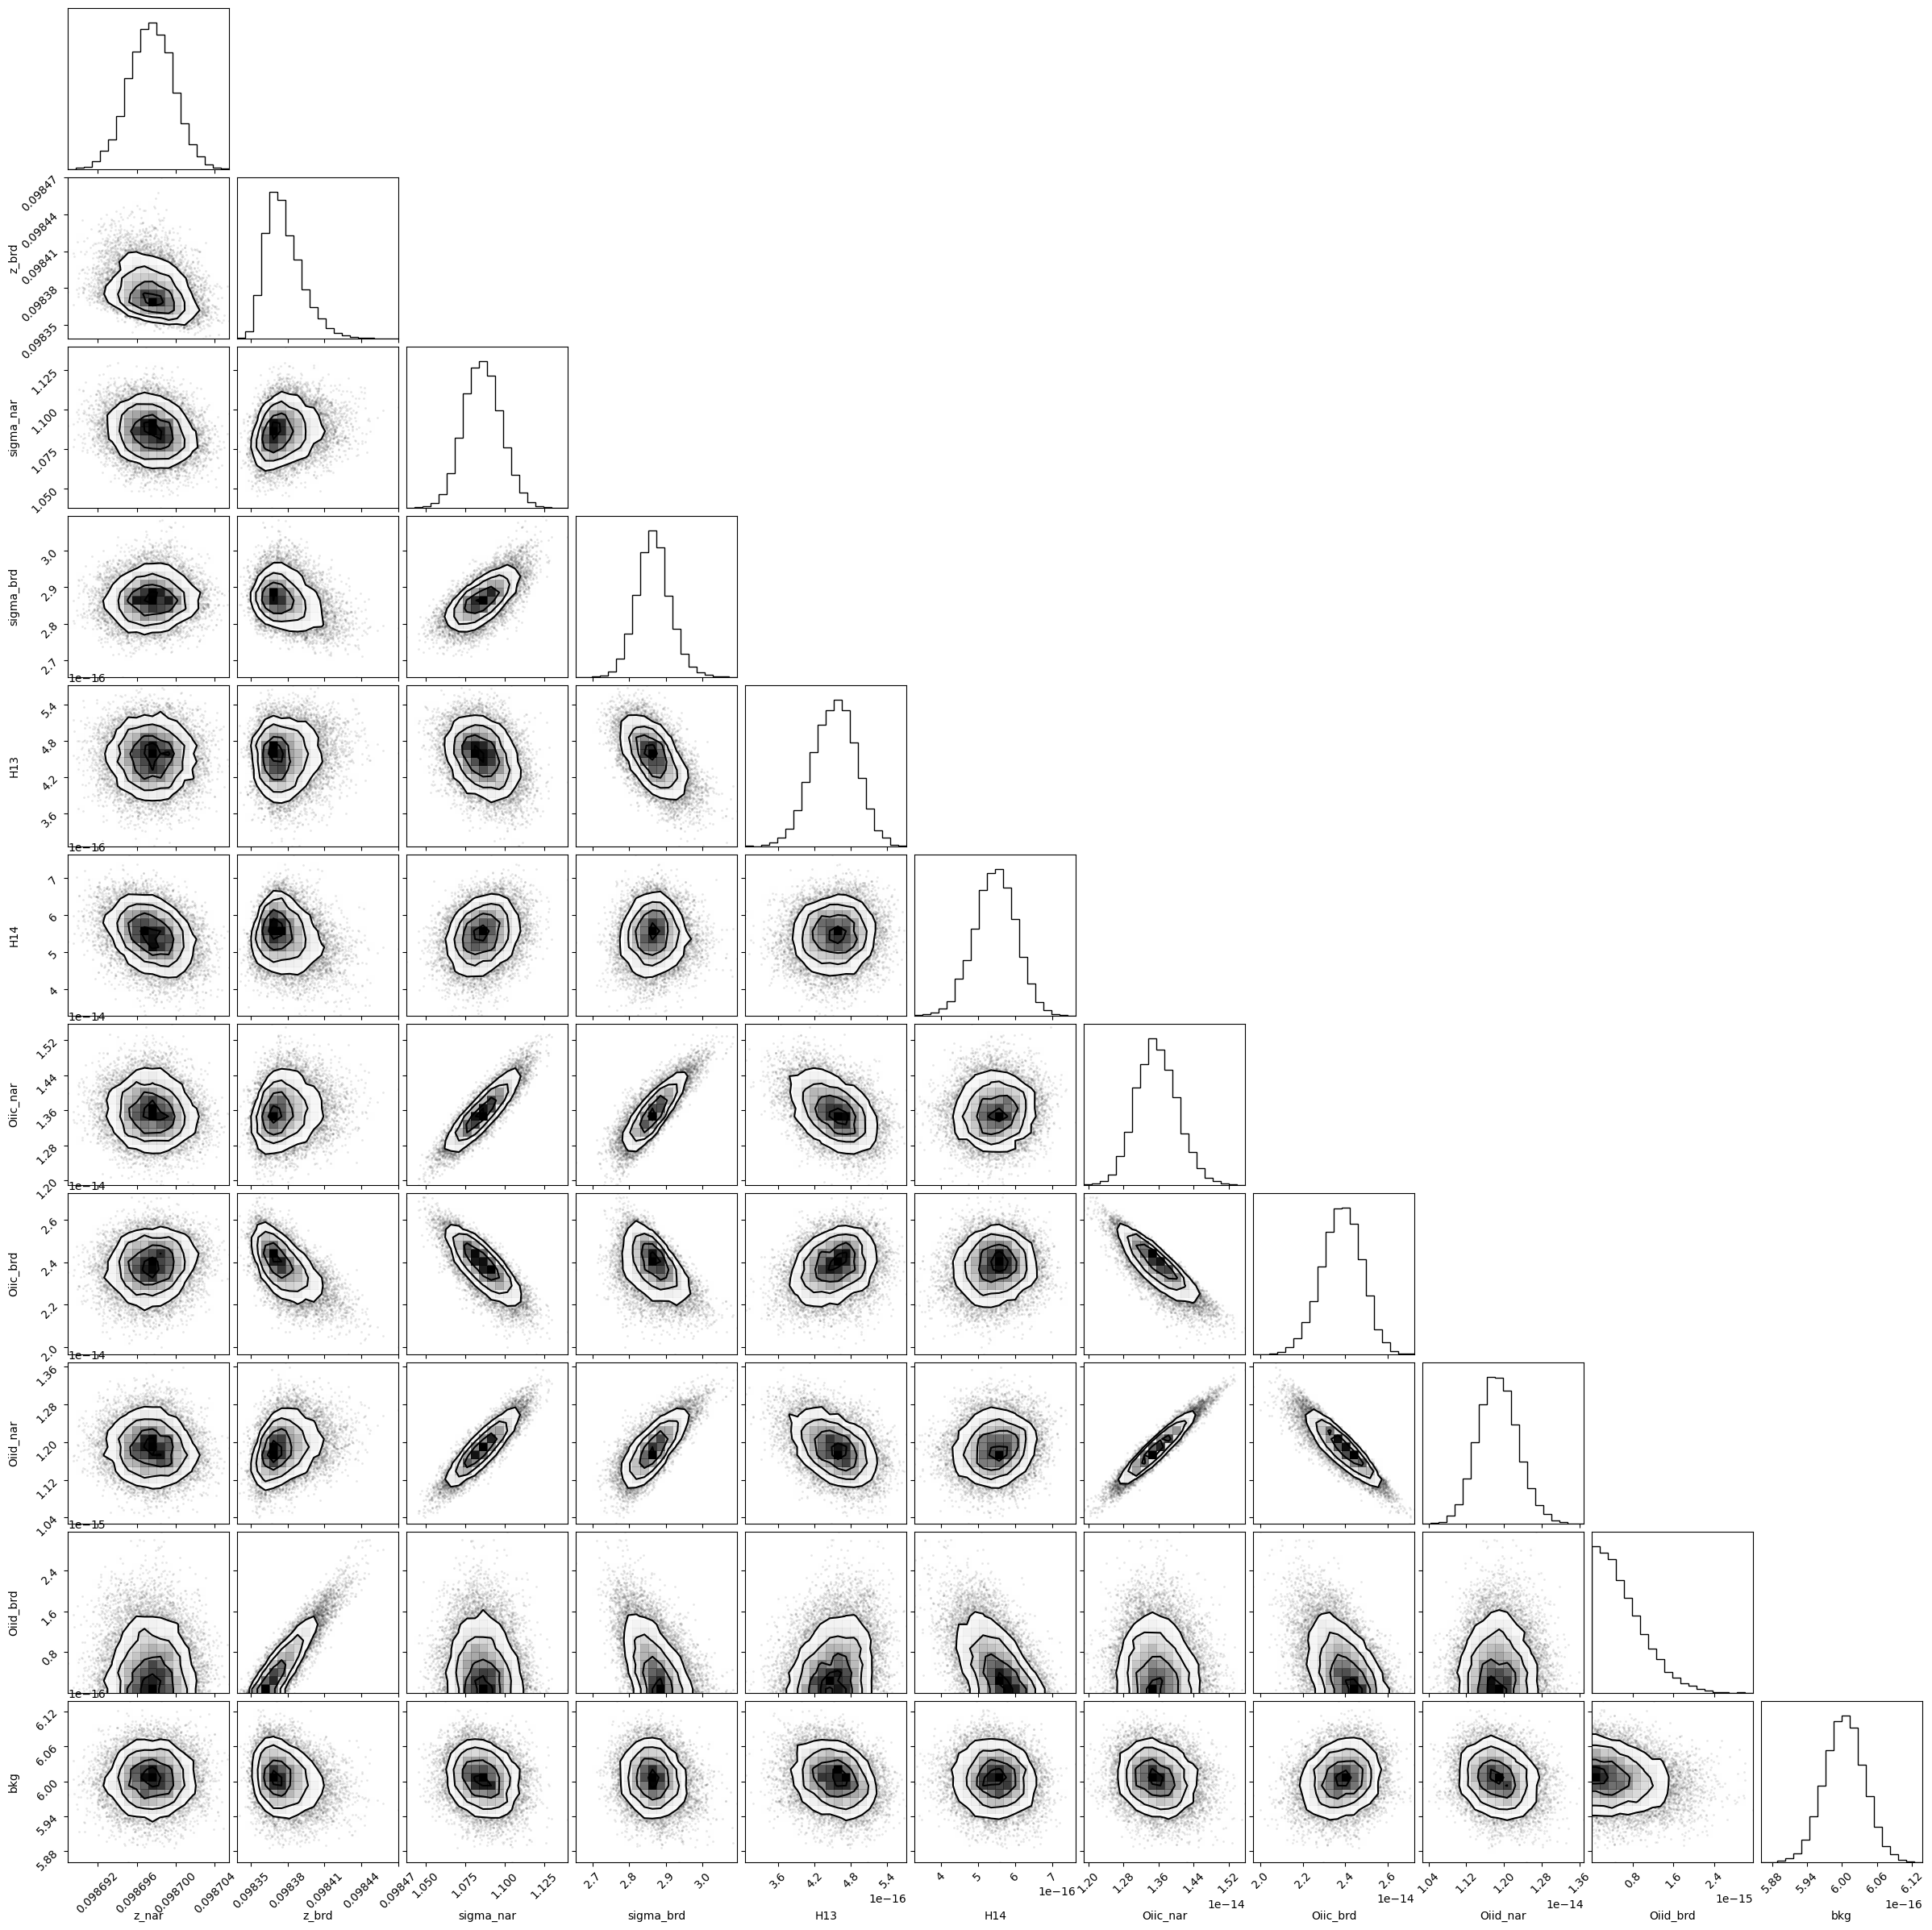

In [96]:
corner.corner(out_oii_3727.flatchain, labels=out_oii_3727.var_names);

In [97]:
out_oii_3727

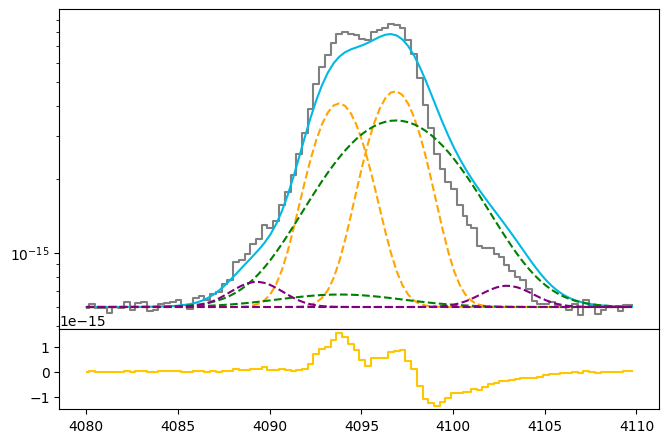

In [98]:
h13_flux = out_oii_3727.flatchain.H13.mean()
h13_std = out_oii_3727.flatchain.H13.std()

oiic_nar_flux = out_oii_3727.flatchain.Oiic_nar.mean()
oiic_nar_std = out_oii_3727.flatchain.Oiic_nar.std()

oiic_brd_flux = out_oii_3727.flatchain.Oiic_brd.mean()
oiic_brd_std = out_oii_3727.flatchain.Oiic_brd.std()

oiid_nar_flux = out_oii_3727.flatchain.Oiid_nar.mean()
oiid_nar_std = out_oii_3727.flatchain.Oiid_nar.std()

oiid_brd_flux = out_oii_3727.flatchain.Oiid_brd.mean()
oiid_brd_std = out_oii_3727.flatchain.Oiid_brd.std()

h14_flux = out_oii_3727.flatchain.H14.mean()
h14_std = out_oii_3727.flatchain.H14.std()

z_oii_3727 = out_oii_3727.flatchain.z_nar.mean()
z_oii_3727_std = out_oii_3727.flatchain.z_nar.std()

bkg_oii_3727 = out_oii_3727.flatchain.bkg.mean()
bkg_oii_3727_std = out_oii_3727.flatchain.bkg.std()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oii_3727.wavelength, oii_3727.flux, color='gray', label='Data', where='mid')

h13 = gaussian(oii_3727.wavelength, h13_flux, wave_cat['H13'], z_oii_3727, sigma_nar_oiii_4959)

oiic_nar = gaussian(oii_3727.wavelength, oiic_nar_flux, wave_cat['[OII]3729'], z_oii_3727, sigma_nar_oiii_4959)
oiic_brd = gaussian(oii_3727.wavelength, oiic_brd_flux, wave_cat['[OII]3729'], z_oii_3727 * z_ratio, sigma_brd_oiii_4959)

oiid_nar = gaussian(oii_3727.wavelength, oiid_nar_flux, wave_cat['[OII]3726'], z_oii_3727, sigma_nar_oiii_4959)
oiid_brd = gaussian(oii_3727.wavelength, oiid_brd_flux, wave_cat['[OII]3726'], z_oii_3727 * z_ratio, sigma_brd_oiii_4959)

h14 = gaussian(oii_3727.wavelength, h14_flux, wave_cat['H14'], z_oii_3727, sigma_nar_oiii_4959)

oiic = oiic_nar + oiic_brd
oiid = oiid_nar + oiid_brd

ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13 + oiic + oiid + h14, color=c[0])
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_nar, ls='--', color='orange')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiic_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + oiid_brd, ls='--', color='green')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h13, ls='--', color='purple')
ax.plot(oii_3727.wavelength, bkg_oii_3727 + h14, ls='--', color='purple')

ax.set_yscale('log')
ax1.step(oii_3727.wavelength, oii_3727.flux - bkg_oii_3727 - oiic - oiid - h13 - h14, color=c[3], where='mid')


#ls_oiid = (wave_cat['[OII]3726'] * (1 + z_oii_3727)) + (3 * sigma_brd_oiii_4959)
#li_oiid = (wave_cat['[OII]3726'] * (1 + z_oii_3727)) - (3 * sigma_brd_oiii_4959)

#ls_oiic = (wave_cat['[OII]3729'] * (1 + z_oii_3727)) + (3 * sigma_brd_oiii_4959)
#li_oiic = (wave_cat['[OII]3729'] * (1 + z_oii_3727)) - (3 * sigma_brd_oiii_4959)

#ax.axvline(ls_oiid, ls='--', color='gray', lw=0.8)
#ax.axvline(li_oiid, ls='--', color='gray', lw=0.8)

#ax.axvline(ls_oiic, ls='--', color='gray', lw=0.8)
#ax.axvline(li_oiic, ls='--', color='gray', lw=0.8)

In [67]:
# EW
EW_OII_3729_nar = ufloat(oiic_nar_flux, oiic_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729_brd = ufloat(oiic_brd_flux, oiic_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3729 = (ufloat(oiic_nar_flux, oiic_nar_std) + ufloat(oiic_brd_flux, oiic_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)

EW_OII_3726_nar = ufloat(oiid_nar_flux, oiid_nar_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726_brd = ufloat(oiid_brd_flux, oiid_brd_std) / ufloat(bkg_oii_3727, bkg_oii_3727_std)
EW_OII_3726 = (ufloat(oiid_nar_flux, oiid_nar_std) + ufloat(oiid_brd_flux, oiid_brd_std)) / ufloat(bkg_oii_3727, bkg_oii_3727_std)